In [15]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy import stats
from scipy.stats import ttest_rel
import scienceplots

In [16]:
DARK_BLUE  = (0.0, 0.4667, 0.7333)
LIGHT_BLUE = (0.2, 0.7333, 0.9333)
GREEN      = (0.0, 0.6, 0.5333)
ORANGE     = (0.9333, 0.4667, 0.2)
RED        = (0.8, 0.2, 0.0667)
PINK       = (0.9333, 0.2, 0.4667)
GRAY       = (0.7333, 0.7333, 0.7333)

SAVE = True

In [17]:
RUNS = {
    "Baseline":
    {
        'folder': "/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/PreTrainingBaseline",
        "color": GRAY
    },
    "FB": 
    {
        "folder": '/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/FB/02_23_22_49_LR_1_PW_04_HigherDeltaBCM_30_17_15_4',
        "color": ORANGE
    },
    "All Inputs→Motor": 
    {
        "folder": '/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/FB_Ablations/02_24_00_23_LR_1_PW_04_NoS_HigherDeltaBCM',
        "color": "#0077BB"
    },
    "Small $\Delta$y Inputs→Motor": 
    {
        "folder": '/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/Freeze/02_24_10_51_LR_1_PW_04__HigherDeltaBCM_Freeze_2345',
        "color": "#1AABFF"
    },
    "Large $\Delta$y Inputs→Motor": 
    {
        "folder": '/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/Freeze/02_24_11_59_LR_1_PW_04__HigherDeltaBCM_Freeze_0167',
        "color":   "#75CDFF"
    }
}

<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
/var/folders/5j/y5kkrfqd203frqztz88nnmqr0000gn/T/ipykernel_89182/1757106017.py:17: SyntaxWarning: invalid escape sequence '\D'
  "Small $\Delta$y Inputs→Motor":
/var/folders/5j/y5kkrfqd203frqztz88nnmqr0000gn/T/ipykernel_89182/1757106017.py:22: SyntaxWarning: invalid escape sequence '\D'
  "Large $\Delta$y Inputs→Motor":


In [18]:
def ema(x, alpha=0.1):
    y = np.zeros_like(x, dtype=float)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i-1]
    return y

In [19]:
# Configuration
ALPHA = 0.05
N = 50

# Process each run
for run in RUNS:
    result_files = glob.glob(os.path.join(RUNS[run]['folder'], "*results.csv"))
    RUNS[run]['results'] = {}
    
    # Initialize collectors
    rolling_means = []
    start_end_collectors = {'start': [], 'end': []}
    
    # Process each network file
    for f in result_files:
        network = f.split('_')[-2]
        results = np.loadtxt(f)
        RUNS[run]['results'][network] = {}
        
        # Rolling mean
        smoothed_results = ema(results, ALPHA)
        RUNS[run]['results'][network]['rolling means'] = smoothed_results
        rolling_means.append(smoothed_results)
        
        # Start and end performance
        start_results = np.mean(results[:N])
        end_results = np.mean(results[-N:])
        RUNS[run]['results'][network]['s'] = start_results
        RUNS[run]['results'][network]['e'] = end_results
        start_end_collectors['start'].append(start_results)
        start_end_collectors['end'].append(end_results)
        
    # Store aggregated results
    RUNS[run]['rolling means'] = np.array(rolling_means)
    RUNS[run]['start'] = np.array(start_end_collectors['start'])
    RUNS[run]['end'] = np.array(start_end_collectors['end'])

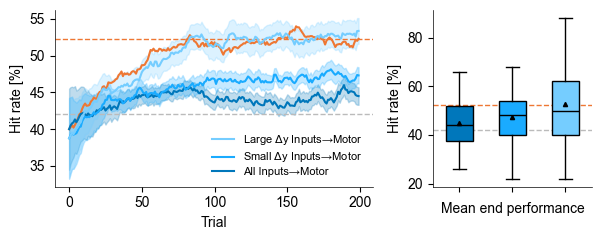

In [20]:
plt.style.use(['nature_d'])
fig, axs = plt.subplot_mosaic(
    [
        ["OT", "SvE"]
    ],
    sharey=False,
    width_ratios=[2,1]
)

BOXPLOT_CONFIG = {
    'widths': 0.5,
    'patch_artist': True,
    'showfliers': False,
    'showmeans': True,
    'meanprops': {
        "markerfacecolor": 'black',
        "markeredgecolor": 'black',
        "markersize": 3
    }
}

# axs['OT'].axhline(40/95 * 100, linestyle='--', color='black', linewidth=1)#, label='Chance')
# axs['SvE'].axhline(40/95 * 100, linestyle='--', color='black', linewidth=1)#, label='Chance')

for i, run in enumerate(RUNS):
    
    # Helper function to style boxplot
    def style_boxplot(box_parts, color):
        for box in box_parts['boxes']:
            box.set_facecolor(color)
            box.set_edgecolor('black')
        for element in ['whiskers', 'caps', 'medians']:
            for item in box_parts[element]:
                item.set_color('black')
                item.set_linewidth(1)
    
    
    if run == "Baseline":
        color = RUNS[run]['color']
        axs['SvE'].axhline(RUNS[run]['end'].mean() * 100, linestyle='--' , color=color, linewidth=1)
        axs['OT'].axhline(RUNS[run]['end'].mean() * 100, linestyle='--' , color=color, linewidth=1,)
        
        continue
        
    if run == "FB":
        data = RUNS[run]['rolling means']* 100
        color = RUNS[run]['color']
        
        # Plot rolling mean with SEM
        _mean = data.mean(axis=0) 
        x = np.arange(len(_mean))
        
        axs['SvE'].axhline(RUNS[run]['end'].mean() * 100, linestyle='--' , color=color, linewidth=1)
        axs['OT'].axhline(RUNS[run]['end'].mean() * 100, linestyle='--' , color=color, linewidth=1,)
        axs["OT"].plot(x,_mean, color=color, alpha=1.0, linewidth=1.5)
        
        continue
        
    else:
        data = RUNS[run]['rolling means']* 100
        color = RUNS[run]['color']
        
        # Plot rolling mean with SEM
        _mean = data.mean(axis=0) 
        sem = data.std(axis=0, ddof=1) / np.sqrt(data.shape[0])
        x = np.arange(len(_mean))
        
        axs["OT"].plot(x, _mean, color=color, alpha=1.0, linewidth=1.5, 
                    label=f'{run}') # (n={len(data)})
        axs["OT"].fill_between(x, _mean - sem, _mean + sem, color=color, alpha=0.25)
        
        # Plot start/end boxplots for main metric
        box_parts = axs["SvE"].boxplot(
            RUNS[run]['end'] * 100,
            positions=[i],
            **BOXPLOT_CONFIG
        )
        style_boxplot(box_parts, color)

# Styling
handles, labels = axs['OT'].get_legend_handles_labels()
axs['OT'].legend(handles[::-1], labels[::-1], labelspacing=0.2)

# Axis labels
axs["OT"].set_xlabel('Trial')
axs["OT"].set_ylabel('Hit rate [%]')
axs["SvE"].set_ylabel('Hit rate [%]')
# axs["SvE"].set_xticklabels([x for _ in range(len(RUNS)) for x in ["Start", "End"]])
# axs["SvE"].set_xticks(range(2,len(RUNS)))
axs["SvE"].set_xticklabels([])
axs["SvE"].set_xlabel("Mean end performance")
    
# w, h = fig.get_size_inches()
# fig.set_size_inches(w, 4)

fig.tight_layout()
if SAVE:
    fig.savefig("output/fig_freeze.pdf", dpi=300)
plt.show()

In [21]:
def get_paired_ttest_statistics(group1, group2, bonferroni_factor, alpha=0.05):
    s = RUNS[group1]['end']
    e = RUNS[group2]['end']
    
    if s.shape != e.shape:
        raise ValueError(f"Shape mismatch: s_acc {s.shape} vs e_acc {e.shape}")

    d = e - s
    n = d.size
    df = n - 1

    mean_s = s.mean()
    mean_e = e.mean()
    mean_diff = d.mean()
    sd_diff = d.std(ddof=1)
    se_diff = sd_diff / np.sqrt(n)

    # Paired t-test (two-sided)
    t_stat_2s, p_val_2s = ttest_rel(e, s)

    # Bonferroni adjustment
    m = int(bonferroni_factor)
    if m <= 0:
        raise ValueError("bonferroni_factor must be a positive integer")

    alpha_adj = alpha / m
    p_val_bonf = min(p_val_2s * m, 1.0)

    # CI using adjusted alpha (Bonferroni-corrected familywise)
    t_crit_bonf = stats.t.ppf(1 - alpha_adj / 2, df=df)
    ci_low_bonf = mean_diff - t_crit_bonf * se_diff
    ci_high_bonf = mean_diff + t_crit_bonf * se_diff

    # (Optional) uncorrected 95% CI for reference
    t_crit = stats.t.ppf(1 - alpha / 2, df=df)
    ci_low = mean_diff - t_crit * se_diff
    ci_high = mean_diff + t_crit * se_diff

    # Effect size: Cohen's dz
    cohens_dz = mean_diff / sd_diff if sd_diff > 0 else np.inf

    # Reporting
    sig_unc = p_val_2s < alpha
    sig_bonf = p_val_2s < alpha_adj   # equivalent and cleaner

    print(f"Paired comparison per seed: {group2} - {group1}")
    print(f"n = {n}")
    print(f"{group1}: mean = {mean_s:.6f}")
    print(f"{group2}: mean = {mean_e:.6f}")
    print(f"mean difference ({group2} - {group1}) = {mean_diff:.6f}")
    print(f"sd(diff) = {sd_diff:.6f}, se(diff) = {se_diff:.6f}")
    print(f"t({df}) = {t_stat_2s:.6f}")
    print(f"p (two-sided, uncorrected) = {p_val_2s:.6g} {'*' if sig_unc else ''}")

    print(f"\nUncorrected 95% CI for mean difference = "
          f"[{ci_low:.6f}, {ci_high:.6f}]")

    print(f"\nBonferroni correction:")
    print(f"m = {m}, alpha_adj = {alpha_adj:.6g}")
    print(f"p_bonf = {p_val_bonf:.6g} {'*' if sig_bonf else ''}")

    ci_level_bonf = 100 * (1 - alpha_adj)
    print(f"Bonferroni-adjusted {ci_level_bonf:.3f}% CI = "
          f"[{ci_low_bonf:.6f}, {ci_high_bonf:.6f}]")

    print(f"\nEffect size:")
    print(f"Cohen's dz = {cohens_dz:.6f}")
    print("--------------------------------------------------\n")

In [22]:
test_pairs = [
    ("Baseline", "All Inputs→Motor"),
    ("Baseline", "Small $\Delta$y Inputs→Motor"),
    ("Baseline", "Large $\Delta$y Inputs→Motor"),
]

for (group1, group2) in test_pairs:
    get_paired_ttest_statistics(group1, group2, 20)

Paired comparison per seed: All Inputs→Motor - Baseline
n = 80
Baseline: mean = 0.420750
All Inputs→Motor: mean = 0.447500
mean difference (All Inputs→Motor - Baseline) = 0.026750
sd(diff) = 0.102275, se(diff) = 0.011435
t(79) = 2.339370
p (two-sided, uncorrected) = 0.0218433 *

Uncorrected 95% CI for mean difference = [0.003990, 0.049510]

Bonferroni correction:
m = 20, alpha_adj = 0.0025
p_bonf = 0.436866 
Bonferroni-adjusted 99.750% CI = [-0.008964, 0.062464]

Effect size:
Cohen's dz = 0.261550
--------------------------------------------------

Paired comparison per seed: Small $\Delta$y Inputs→Motor - Baseline
n = 80
Baseline: mean = 0.420750
Small $\Delta$y Inputs→Motor: mean = 0.472250
mean difference (Small $\Delta$y Inputs→Motor - Baseline) = 0.051500
sd(diff) = 0.106201, se(diff) = 0.011874
t(79) = 4.337326
p (two-sided, uncorrected) = 4.21927e-05 *

Uncorrected 95% CI for mean difference = [0.027866, 0.075134]

Bonferroni correction:
m = 20, alpha_adj = 0.0025
p_bonf = 0.000

<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
/var/folders/5j/y5kkrfqd203frqztz88nnmqr0000gn/T/ipykernel_89182/802468954.py:3: SyntaxWarning: invalid escape sequence '\D'
  ("Baseline", "Small $\Delta$y Inputs→Motor"),
/var/folders/5j/y5kkrfqd203frqztz88nnmqr0000gn/T/ipykernel_89182/802468954.py:4: SyntaxWarning: invalid escape sequence '\D'
  ("Baseline", "Large $\Delta$y Inputs→Motor"),


In [23]:
test_pairs = [
    ("FB", "All Inputs→Motor"),
    ("FB", "Small $\Delta$y Inputs→Motor"),
    ("FB", "Large $\Delta$y Inputs→Motor"),
]

for (group1, group2) in test_pairs:
    get_paired_ttest_statistics(group1, group2, 20)

Paired comparison per seed: All Inputs→Motor - FB
n = 80
FB: mean = 0.522500
All Inputs→Motor: mean = 0.447500
mean difference (All Inputs→Motor - FB) = -0.075000
sd(diff) = 0.114891, se(diff) = 0.012845
t(79) = -5.838742
p (two-sided, uncorrected) = 1.11266e-07 *

Uncorrected 95% CI for mean difference = [-0.100568, -0.049432]

Bonferroni correction:
m = 20, alpha_adj = 0.0025
p_bonf = 2.22532e-06 *
Bonferroni-adjusted 99.750% CI = [-0.115119, -0.034881]

Effect size:
Cohen's dz = -0.652791
--------------------------------------------------

Paired comparison per seed: Small $\Delta$y Inputs→Motor - FB
n = 80
FB: mean = 0.522500
Small $\Delta$y Inputs→Motor: mean = 0.472250
mean difference (Small $\Delta$y Inputs→Motor - FB) = -0.050250
sd(diff) = 0.123000, se(diff) = 0.013752
t(79) = -3.654056
p (two-sided, uncorrected) = 0.000462798 *

Uncorrected 95% CI for mean difference = [-0.077622, -0.022878]

Bonferroni correction:
m = 20, alpha_adj = 0.0025
p_bonf = 0.00925596 *
Bonferroni-a

<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
/var/folders/5j/y5kkrfqd203frqztz88nnmqr0000gn/T/ipykernel_89182/3059237179.py:3: SyntaxWarning: invalid escape sequence '\D'
  ("FB", "Small $\Delta$y Inputs→Motor"),
/var/folders/5j/y5kkrfqd203frqztz88nnmqr0000gn/T/ipykernel_89182/3059237179.py:4: SyntaxWarning: invalid escape sequence '\D'
  ("FB", "Large $\Delta$y Inputs→Motor"),
